# ICA Benchmark For PhysioNet Motor Imagery

This notebook builds a fresh left-vs-right hand motor imagery benchmark on the PhysioNet EEG Motor Movement/Imagery dataset using an ICA cleaning stage before epoching and model training.

Flow:

- load runs `4`, `8`, and `12`
- standardize channel names and montage
- resample to a common rate
- fit ICA per subject and remove frontal eye-artifact components automatically
- epoch, normalize, benchmark models, and plot results in between sections


In [1]:
import random
import time
import warnings
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from braindecode.models import (
    ATCNet,
    CTNet,
    Deep4Net,
    EEGNet,
    FBCNet,
    FBLightConvNet,
    AttentionBaseNet,
    ShallowFBCSPNet,
)
from mne import Epochs, pick_types
from mne.channels import make_standard_montage
from mne.datasets import eegbci
from mne.decoding import CSP
from mne.io import concatenate_raws, read_raw_edf
from mne.preprocessing import ICA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from torch.utils.data import DataLoader, TensorDataset


warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("ERROR")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 7
DATA_ROOT = Path("/NAS/aniruddham/mne/data")
RUNS = [4, 8, 12]
EPOCH_WINDOW = (0.0, 4.0)
CROP_WINDOW = (0.5, 4.0)
RESAMPLE_SFREQ = 160.0
FILTER_BAND = (8.0, 30.0)
ICA_FILTER_BAND = (1.0, 40.0)
ICA_METHOD = "fastica"
ICA_N_COMPONENTS = 0.99
ICA_EOG_THRESHOLD = "auto"
ICA_FRONTAL_CHANNELS = ["Fp1", "Fp2", "Fpz"]
ICA_MAX_EOG_COMPONENTS_PER_CHANNEL = 2
TEST_SIZE = 0.2
VAL_SIZE = 0.2
MAX_SUBJECTS = None  # Set to a small number like 10 for fast iteration.
BATCH_SIZE = 64
MAX_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 3
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MIN_CHANNEL_TOLERANCE = 0.02
SENSORIMOTOR_CHANNEL_SETS = {
    "motor_strip_3": ["C3", "Cz", "C4"],
    "motor_strip_5": ["FC3", "C3", "Cz", "C4", "FC4"],
    "sensorimotor_9": ["FC3", "FCz", "FC4", "C3", "Cz", "C4", "CP3", "CPz", "CP4"],
    "sensorimotor_17": [
        "FC5",
        "FC3",
        "FC1",
        "FCz",
        "FC2",
        "FC4",
        "FC6",
        "C5",
        "C3",
        "C1",
        "Cz",
        "C2",
        "C4",
        "C6",
        "CP3",
        "CPz",
        "CP4",
    ],
}
MODEL_NAMES = [
    "CSP + LDA",
    "EEGNet",
    "ShallowConvNet",
    "DeepConvNet",
    "AttentionBaseNet",
    "CTNet",
    "FBLightConvNet",
    "FBCNet",
    "ATCNet",
]
CHANNEL_STUDY_MODELS = None
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MONTAGE = make_standard_montage("standard_1005")

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

print(f"Using device: {DEVICE}")


Using device: cuda


In [2]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def infer_available_subjects(data_root: Path = DATA_ROOT) -> list[int]:
    return sorted(
        int(path.name[1:])
        for path in data_root.glob("S[0-9][0-9][0-9]")
        if path.is_dir()
    )


def local_run_paths(
    subject: int, runs: list[int], data_root: Path = DATA_ROOT
) -> list[Path]:
    subject_name = f"S{subject:03d}"
    return [data_root / subject_name / f"{subject_name}R{run:02d}.edf" for run in runs]


def load_subject_raw(subject: int, runs: list[int] = RUNS) -> mne.io.BaseRaw:
    raw_paths = local_run_paths(subject, runs)
    if not all(path.exists() for path in raw_paths):
        missing = [path.name for path in raw_paths if not path.exists()]
        raise FileNotFoundError(
            f"Missing EDF files for subject {subject:03d}: {missing}"
        )

    raw = concatenate_raws(
        [read_raw_edf(path, preload=True, verbose="ERROR") for path in raw_paths]
    )
    eegbci.standardize(raw)
    raw.pick("eeg")
    raw.set_montage(MONTAGE, match_case=False, on_missing="warn")
    raw.set_eeg_reference("average", projection=False, verbose="ERROR")
    raw.resample(RESAMPLE_SFREQ, verbose="ERROR")
    return raw


def run_ica_cleaning(
    raw: mne.io.BaseRaw,
) -> tuple[mne.io.BaseRaw, ICA, list[int], dict]:
    raw_for_ica = raw.copy().filter(
        *ICA_FILTER_BAND,
        fir_design="firwin",
        skip_by_annotation="edge",
        verbose="ERROR",
    )
    ica = ICA(
        n_components=ICA_N_COMPONENTS,
        method=ICA_METHOD,
        random_state=SEED,
        max_iter="auto",
    )
    ica.fit(raw_for_ica, picks="eeg", verbose="ERROR")

    exclude = []
    score_book = {}
    for ch_name in ICA_FRONTAL_CHANNELS:
        if ch_name not in raw_for_ica.ch_names:
            continue
        inds, scores = ica.find_bads_eog(
            raw_for_ica,
            ch_name=ch_name,
            threshold=ICA_EOG_THRESHOLD,
            verbose="ERROR",
        )
        if len(inds) > 0:
            exclude.extend(inds[:ICA_MAX_EOG_COMPONENTS_PER_CHANNEL])
            score_book[ch_name] = scores

    exclude = sorted(set(exclude))
    cleaned = raw.copy()
    ica.exclude = exclude
    ica.apply(cleaned, verbose="ERROR")

    stats = {
        "n_components": int(ica.n_components_),
        "n_excluded": len(exclude),
        "excluded_components": exclude,
        "frontal_channels_used": [
            ch for ch in ICA_FRONTAL_CHANNELS if ch in raw_for_ica.ch_names
        ],
    }
    return cleaned, ica, exclude, stats


def load_subject_epochs(subject: int, runs: list[int] = RUNS) -> dict:
    raw = load_subject_raw(subject, runs)
    cleaned_raw, ica, exclude, ica_stats = run_ica_cleaning(raw)
    cleaned_raw.annotations.rename({"T1": "left_hand", "T2": "right_hand"})
    cleaned_raw.filter(
        *FILTER_BAND, fir_design="firwin", skip_by_annotation="edge", verbose="ERROR"
    )

    events, event_map = mne.events_from_annotations(cleaned_raw, verbose="ERROR")
    epochs = Epochs(
        cleaned_raw,
        events,
        event_id={
            "left_hand": event_map["left_hand"],
            "right_hand": event_map["right_hand"],
        },
        tmin=EPOCH_WINDOW[0],
        tmax=EPOCH_WINDOW[1],
        proj=False,
        picks=pick_types(
            cleaned_raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads"
        ),
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose="ERROR",
    ).crop(*CROP_WINDOW)

    if len(epochs.times) % 2 != 0:
        epochs.crop(tmin=epochs.tmin, tmax=epochs.times[-2])

    X = epochs.get_data(copy=False).astype(np.float32)
    mean = X.mean(axis=2, keepdims=True)
    std = X.std(axis=2, keepdims=True) + 1e-6
    X = (X - mean) / std
    y = (epochs.events[:, -1] == event_map["right_hand"]).astype(np.int64)

    return {
        "subject": subject,
        "X": X,
        "y": y,
        "epochs": epochs,
        "ica": ica,
        "ica_stats": ica_stats,
    }


def build_dataset(subjects: list[int] | None = None) -> dict:
    available_subjects = infer_available_subjects()
    if subjects is None:
        subjects = available_subjects
    if MAX_SUBJECTS is not None:
        subjects = subjects[:MAX_SUBJECTS]
    if not subjects:
        raise RuntimeError(f"No subjects were found under {DATA_ROOT}")

    X_parts = []
    y_parts = []
    groups = []
    kept_subjects = []
    ica_rows = []
    channel_names = None
    chs_info = None
    example_epochs = None

    for subject in subjects:
        loaded = load_subject_epochs(subject)
        if channel_names is None:
            channel_names = loaded["epochs"].ch_names
            chs_info = deepcopy(loaded["epochs"].info["chs"])
            example_epochs = loaded["epochs"].copy()
        elif loaded["epochs"].ch_names != channel_names:
            raise RuntimeError(f"Channel mismatch for subject {subject:03d}")

        X_parts.append(loaded["X"])
        y_parts.append(loaded["y"])
        groups.append(np.full(len(loaded["y"]), subject))
        kept_subjects.append(subject)
        ica_rows.append(
            {
                "subject": subject,
                "excluded_components": len(loaded["ica_stats"]["excluded_components"]),
                "component_ids": loaded["ica_stats"]["excluded_components"],
                "ica_components_fit": loaded["ica_stats"]["n_components"],
            }
        )

    return {
        "X": np.concatenate(X_parts, axis=0),
        "y": np.concatenate(y_parts, axis=0),
        "groups": np.concatenate(groups, axis=0),
        "subjects": kept_subjects,
        "channel_names": list(channel_names),
        "chs_info": chs_info,
        "sfreq": float(example_epochs.info["sfreq"]),
        "example_epochs": example_epochs,
        "ica_summary": pd.DataFrame(ica_rows),
    }


set_seed()
dataset = build_dataset()

dataset_summary = pd.DataFrame(
    {
        "metric": [
            "subjects_used",
            "epochs_total",
            "left_trials",
            "right_trials",
            "channels",
            "sampling_rate_hz",
            "samples_per_epoch",
            "mean_ica_components_removed",
        ],
        "value": [
            len(dataset["subjects"]),
            len(dataset["y"]),
            int((dataset["y"] == 0).sum()),
            int((dataset["y"] == 1).sum()),
            len(dataset["channel_names"]),
            dataset["sfreq"],
            dataset["X"].shape[-1],
            dataset["ica_summary"]["excluded_components"].mean(),
        ],
    }
)

display(dataset_summary)
display(dataset["ica_summary"].head())


/home/aniruddham/code/project/.venv/lib/python3.14/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


,metric,value
0,subjects_used,109.000000
1,epochs_total,4898.000000
2,left_trials,2470.000000
3,right_trials,2428.000000
4,channels,64.000000
5,sampling_rate_hz,160.000000
6,samples_per_epoch,560.000000
7,mean_ica_components_removed,1.972477


,subject,excluded_components,component_ids,ica_components_fit
0,1,1,[0],31
1,2,2,"[0, 1]",43
2,3,3,"[0, 1, 2]",31
3,4,2,"[1, 2]",34
4,5,2,"[0, 1]",47


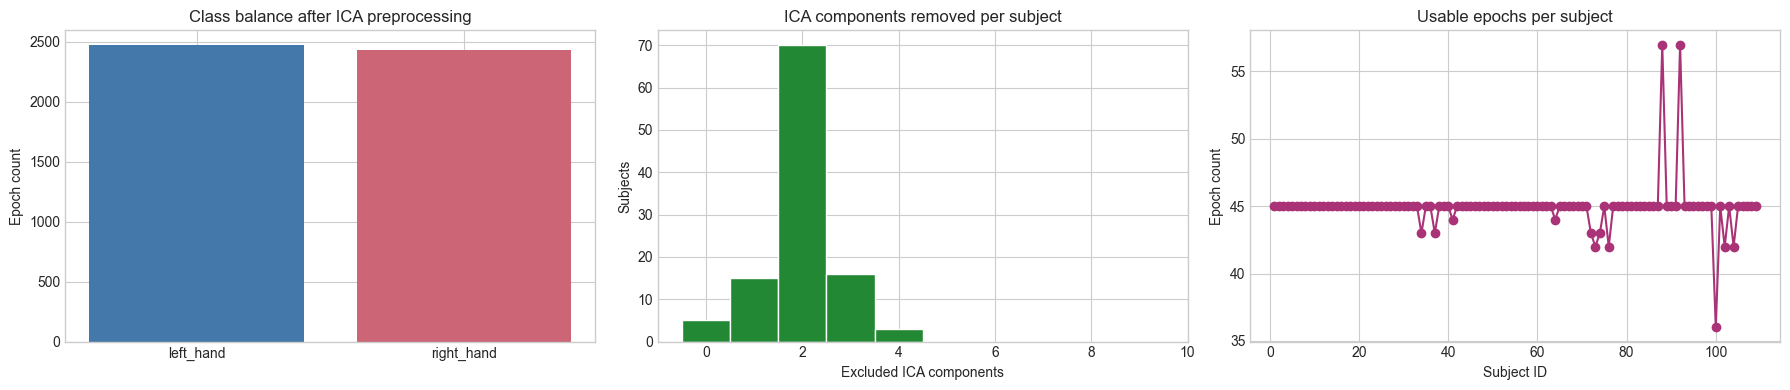

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

class_counts = (
    pd.Series(dataset["y"])
    .map({0: "left_hand", 1: "right_hand"})
    .value_counts()
    .sort_index()
)
axes[0].bar(class_counts.index, class_counts.values, color=["#4477AA", "#CC6677"])
axes[0].set_title("Class balance after ICA preprocessing")
axes[0].set_ylabel("Epoch count")

axes[1].hist(
    dataset["ica_summary"]["excluded_components"],
    bins=np.arange(-0.5, 10.5, 1),
    color="#228833",
    edgecolor="white",
)
axes[1].set_title("ICA components removed per subject")
axes[1].set_xlabel("Excluded ICA components")
axes[1].set_ylabel("Subjects")

epochs_per_subject = pd.Series(dataset["groups"]).value_counts().sort_index()
axes[2].plot(
    epochs_per_subject.index,
    epochs_per_subject.values,
    marker="o",
    linewidth=1.5,
    color="#AA3377",
)
axes[2].set_title("Usable epochs per subject")
axes[2].set_xlabel("Subject ID")
axes[2].set_ylabel("Epoch count")

plt.tight_layout()
plt.show()


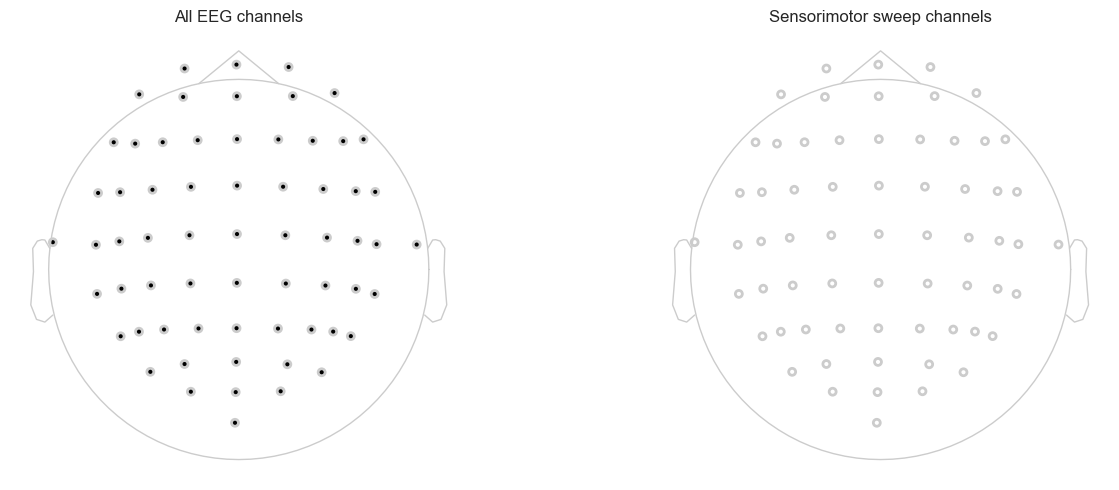

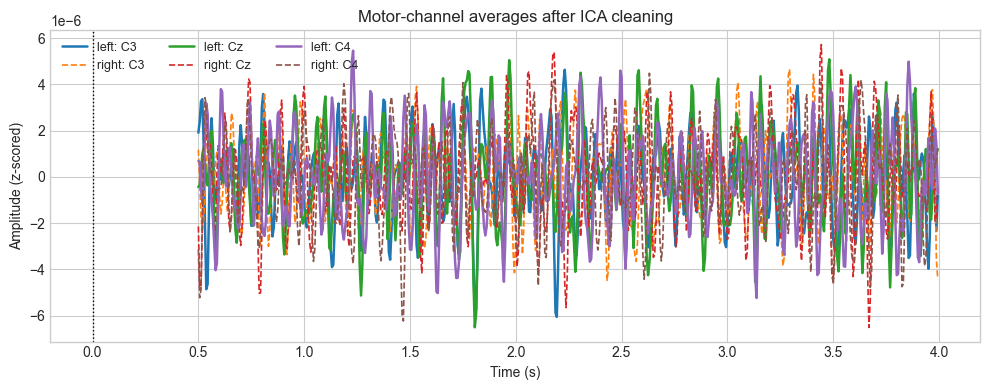

In [4]:
sensorimotor_union = []
for subset in SENSORIMOTOR_CHANNEL_SETS.values():
    sensorimotor_union.extend(subset)
sensorimotor_union = [
    ch for ch in dict.fromkeys(sensorimotor_union) if ch in dataset["channel_names"]
]
sensorimotor_indices = [
    dataset["example_epochs"].ch_names.index(ch) for ch in sensorimotor_union
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mne.viz.plot_sensors(
    dataset["example_epochs"].info, axes=axes[0], show=False, kind="topomap"
)
axes[0].set_title("All EEG channels")
mne.viz.plot_sensors(
    dataset["example_epochs"].info,
    axes=axes[1],
    show=False,
    kind="topomap",
    ch_groups=[sensorimotor_indices],
)
axes[1].set_title("Sensorimotor sweep channels")
plt.tight_layout()
plt.show()

motor_channels = [
    ch for ch in ["C3", "Cz", "C4"] if ch in dataset["example_epochs"].ch_names
]
if motor_channels:
    fig, ax = plt.subplots(figsize=(10, 4))
    left_evoked = dataset["example_epochs"]["left_hand"].average().pick(motor_channels)
    right_evoked = (
        dataset["example_epochs"]["right_hand"].average().pick(motor_channels)
    )
    for ch_name in motor_channels:
        idx = left_evoked.ch_names.index(ch_name)
        ax.plot(
            left_evoked.times,
            left_evoked.data[idx],
            label=f"left: {ch_name}",
            linewidth=1.8,
        )
        ax.plot(
            right_evoked.times,
            right_evoked.data[idx],
            label=f"right: {ch_name}",
            linewidth=1.2,
            linestyle="--",
        )
    ax.axvline(0.0, color="black", linestyle=":", linewidth=1)
    ax.set_title("Motor-channel averages after ICA cleaning")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (z-scored)")
    ax.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    plt.show()


In [5]:
def make_subject_split(
    groups: np.ndarray,
    test_size: float = TEST_SIZE,
    val_size: float = VAL_SIZE,
    seed: int = SEED,
) -> dict:
    index = np.arange(len(groups))
    outer = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_val_idx, test_idx = next(outer.split(index, groups=groups))
    inner_groups = groups[train_val_idx]
    inner_index = np.arange(len(train_val_idx))
    inner = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=seed + 1)
    inner_train_rel, inner_val_rel = next(inner.split(inner_index, groups=inner_groups))
    return {
        "train": train_val_idx[inner_train_rel],
        "val": train_val_idx[inner_val_rel],
        "test": test_idx,
    }


def make_loader(X: np.ndarray, y: np.ndarray, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False)


def unpack_logits(logits):
    if isinstance(logits, (tuple, list)):
        logits = logits[0]
    while logits.ndim > 2 and logits.shape[-1] == 1:
        logits = logits.squeeze(-1)
    if logits.ndim > 2:
        logits = logits.mean(dim=tuple(range(2, logits.ndim)))
    return logits


@torch.no_grad()
def evaluate_torch_model(
    model: nn.Module, loader: DataLoader, criterion: nn.Module
) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    for batch_X, batch_y in loader:
        batch_X = batch_X.to(DEVICE)
        batch_y = batch_y.to(DEVICE)
        logits = unpack_logits(model(batch_X))
        loss = criterion(logits, batch_y)
        total_loss += loss.item() * len(batch_y)
        total_correct += (logits.argmax(dim=1) == batch_y).sum().item()
        total_count += len(batch_y)
    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)


def build_torch_model(
    model_name: str, n_chans: int, n_times: int, sfreq: float, chs_info: list[dict]
) -> nn.Module:
    common = dict(
        n_chans=n_chans, n_outputs=2, n_times=n_times, sfreq=sfreq, chs_info=chs_info
    )
    if model_name == "EEGNet":
        return EEGNet(**common)
    if model_name == "ShallowConvNet":
        return ShallowFBCSPNet(**common)
    if model_name == "DeepConvNet":
        return Deep4Net(**common)
    if model_name == "AttentionBaseNet":
        return AttentionBaseNet(**common)
    if model_name == "CTNet":
        return CTNet(**common)
    if model_name == "FBLightConvNet":
        return FBLightConvNet(**common)
    if model_name == "FBCNet":
        return FBCNet(**common)
    if model_name == "ATCNet":
        return ATCNet(**common)
    raise KeyError(f"Unknown model name: {model_name}")


def run_csp_lda(X_train, y_train, X_val, y_val, X_test, y_test) -> dict:
    start = time.perf_counter()
    clf = Pipeline(
        [
            (
                "csp",
                CSP(
                    n_components=max(2, min(8, X_train.shape[1])),
                    reg="oas",
                    log=True,
                    norm_trace=False,
                ),
            ),
            ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
        ]
    )
    clf.fit(X_train, y_train)
    train_time = time.perf_counter() - start
    return {
        "val_accuracy": clf.score(X_val, y_val),
        "test_accuracy": clf.score(X_test, y_test),
        "train_time_s": train_time,
        "best_epoch": 1,
        "status": "ok",
    }


def run_torch_benchmark(
    model_name, X_train, y_train, X_val, y_val, X_test, y_test, sfreq, chs_info
) -> dict:
    set_seed(SEED)
    train_loader = make_loader(X_train, y_train, shuffle=True)
    val_loader = make_loader(X_val, y_val, shuffle=False)
    test_loader = make_loader(X_test, y_test, shuffle=False)

    model = build_torch_model(
        model_name=model_name,
        n_chans=X_train.shape[1],
        n_times=X_train.shape[2],
        sfreq=sfreq,
        chs_info=chs_info,
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    best_state = None
    best_val_accuracy = -np.inf
    best_epoch = 0
    patience_counter = 0
    start = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = unpack_logits(model(batch_X))
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

        _, val_accuracy = evaluate_torch_model(model, val_loader, criterion)
        if val_accuracy > best_val_accuracy + 1e-4:
            best_val_accuracy = val_accuracy
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                break

    train_time = time.perf_counter() - start
    if best_state is not None:
        model.load_state_dict(best_state)

    _, final_val_accuracy = evaluate_torch_model(model, val_loader, criterion)
    _, test_accuracy = evaluate_torch_model(model, test_loader, criterion)
    return {
        "val_accuracy": final_val_accuracy,
        "test_accuracy": test_accuracy,
        "train_time_s": train_time,
        "best_epoch": best_epoch,
        "status": "ok",
    }


def benchmark_models(
    X, y, groups, channel_names, chs_info, sfreq, model_names=None, split=None
):
    if split is None:
        split = make_subject_split(groups)
    model_names = model_names or MODEL_NAMES
    X_train, y_train = X[split["train"]], y[split["train"]]
    X_val, y_val = X[split["val"]], y[split["val"]]
    X_test, y_test = X[split["test"]], y[split["test"]]

    results = []
    for model_name in model_names:
        print(f"Running {model_name} on {len(channel_names)} channels...")
        try:
            if model_name == "CSP + LDA":
                result = run_csp_lda(X_train, y_train, X_val, y_val, X_test, y_test)
            else:
                result = run_torch_benchmark(
                    model_name,
                    X_train,
                    y_train,
                    X_val,
                    y_val,
                    X_test,
                    y_test,
                    sfreq,
                    chs_info,
                )
        except Exception as exc:
            result = {
                "val_accuracy": np.nan,
                "test_accuracy": np.nan,
                "train_time_s": np.nan,
                "best_epoch": np.nan,
                "status": f"failed: {type(exc).__name__}: {exc}",
            }
        result.update({"model": model_name, "n_channels": len(channel_names)})
        results.append(result)

    return pd.DataFrame(results), split


def resolve_channel_subsets(
    channel_names: list[str], desired_subsets: dict[str, list[str]]
) -> dict[str, list[str]]:
    resolved = {}
    for subset_name, subset_channels in desired_subsets.items():
        present = [ch for ch in subset_channels if ch in channel_names]
        if len(present) >= 3:
            resolved[subset_name] = present
    return resolved


def summarize_min_channels(
    results: pd.DataFrame, tolerance: float = MIN_CHANNEL_TOLERANCE
) -> pd.DataFrame:
    successful = results.query("status == 'ok'").copy()
    rows = []
    for model_name, model_df in successful.groupby("model"):
        ranked = model_df.sort_values(
            ["n_channels", "test_accuracy"], ascending=[True, False]
        ).reset_index(drop=True)
        best_accuracy = ranked["test_accuracy"].max()
        eligible = ranked[ranked["test_accuracy"] >= best_accuracy - tolerance].iloc[0]
        rows.append(
            {
                "model": model_name,
                "best_accuracy": best_accuracy,
                "min_channels_within_tolerance": int(eligible["n_channels"]),
                "recommended_subset": eligible["subset"],
                "recommended_accuracy": eligible["test_accuracy"],
            }
        )
    return pd.DataFrame(rows).sort_values(
        ["min_channels_within_tolerance", "recommended_accuracy"],
        ascending=[True, False],
    )


In [6]:
all_channel_results, split_idx = benchmark_models(
    X=dataset["X"],
    y=dataset["y"],
    groups=dataset["groups"],
    channel_names=dataset["channel_names"],
    chs_info=dataset["chs_info"],
    sfreq=dataset["sfreq"],
    model_names=MODEL_NAMES,
)

successful_all = (
    all_channel_results.query("status == 'ok'")
    .sort_values("test_accuracy", ascending=False)
    .reset_index(drop=True)
)
display(
    all_channel_results.sort_values(
        ["status", "test_accuracy"], ascending=[True, False]
    )
)


Running CSP + LDA on 64 channels...
Running EEGNet on 64 channels...
Running ShallowConvNet on 64 channels...
Running DeepConvNet on 64 channels...
Running AttentionBaseNet on 64 channels...
Running CTNet on 64 channels...


/home/aniruddham/code/project/.venv/lib/python3.14/site-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1024.)
  return F.conv2d(


Running FBLightConvNet on 64 channels...
Running FBCNet on 64 channels...
Running ATCNet on 64 channels...


,val_accuracy,test_accuracy,train_time_s,best_epoch,status,model,n_channels
6,0.660891,0.599596,7.950674,8,ok,FBLightConvNet,64
7,0.654703,0.595551,9.348016,9,ok,FBCNet,64
1,0.681931,0.572295,12.338199,11,ok,EEGNet,64
3,0.585396,0.560162,6.871665,9,ok,DeepConvNet,64
2,0.646040,0.557128,5.151088,8,ok,ShallowConvNet,64
4,0.674505,0.554095,14.080848,7,ok,AttentionBaseNet,64
5,0.587871,0.548028,13.238335,4,ok,CTNet,64
0,0.620050,0.537917,138.995414,1,ok,CSP + LDA,64
8,0.532178,0.520728,15.119923,5,ok,ATCNet,64


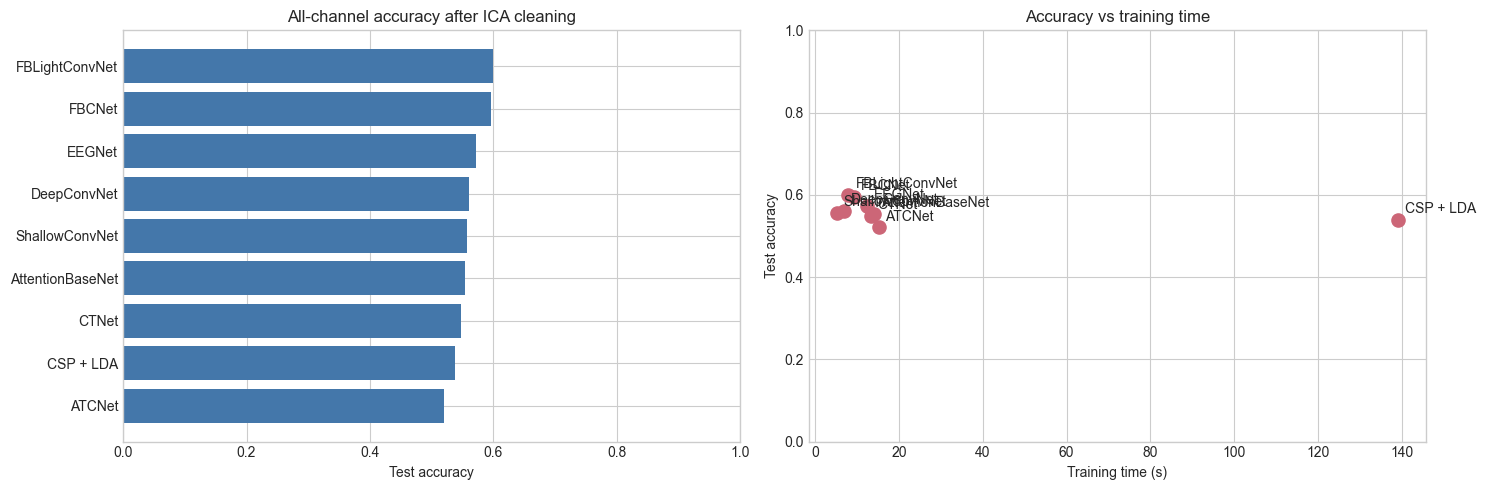

In [7]:
if not successful_all.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    ranked = successful_all.sort_values("test_accuracy", ascending=True)
    axes[0].barh(ranked["model"], ranked["test_accuracy"], color="#4477AA")
    axes[0].set_title("All-channel accuracy after ICA cleaning")
    axes[0].set_xlabel("Test accuracy")
    axes[0].set_xlim(0.0, 1.0)

    axes[1].scatter(
        successful_all["train_time_s"],
        successful_all["test_accuracy"],
        s=90,
        color="#CC6677",
    )
    for _, row in successful_all.iterrows():
        axes[1].annotate(
            row["model"],
            (row["train_time_s"], row["test_accuracy"]),
            xytext=(5, 5),
            textcoords="offset points",
        )
    axes[1].set_title("Accuracy vs training time")
    axes[1].set_xlabel("Training time (s)")
    axes[1].set_ylabel("Test accuracy")
    axes[1].set_ylim(0.0, 1.0)

    plt.tight_layout()
    plt.show()


In [8]:
available_channel_sets = resolve_channel_subsets(
    dataset["channel_names"], SENSORIMOTOR_CHANNEL_SETS
)
display(
    pd.DataFrame(
        {
            "subset": list(available_channel_sets.keys()),
            "n_channels": [len(chs) for chs in available_channel_sets.values()],
            "channels": [", ".join(chs) for chs in available_channel_sets.values()],
        }
    )
)

channel_study_models = CHANNEL_STUDY_MODELS
if channel_study_models is None:
    channel_study_models = successful_all["model"].tolist()

name_to_idx = {name: idx for idx, name in enumerate(dataset["channel_names"])}
frames = []
for subset_name, subset_channels in available_channel_sets.items():
    picks = [name_to_idx[ch] for ch in subset_channels]
    subset_results, _ = benchmark_models(
        X=dataset["X"][:, picks, :],
        y=dataset["y"],
        groups=dataset["groups"],
        channel_names=subset_channels,
        chs_info=[deepcopy(dataset["chs_info"][idx]) for idx in picks],
        sfreq=dataset["sfreq"],
        model_names=channel_study_models,
        split=split_idx,
    )
    subset_results["subset"] = subset_name
    subset_results["subset_channels"] = ", ".join(subset_channels)
    frames.append(subset_results)

subset_channel_results = (
    pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
)
all_channel_for_comparison = all_channel_results.copy()
all_channel_for_comparison["subset"] = "all_channels"
all_channel_for_comparison["subset_channels"] = ", ".join(dataset["channel_names"])
channel_sweep_results = pd.concat(
    [all_channel_for_comparison, subset_channel_results], ignore_index=True
)

display(
    channel_sweep_results.sort_values(
        ["model", "n_channels", "test_accuracy"], ascending=[True, True, False]
    )
)


,subset,n_channels,channels
0,motor_strip_3,3,"C3, Cz, C4"
1,motor_strip_5,5,"FC3, C3, Cz, C4, FC4"
2,sensorimotor_9,9,"FC3, FCz, FC4, C3, Cz, C4, CP3, CPz, CP4"
3,sensorimotor_17,17,"FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1,..."


Running FBLightConvNet on 3 channels...
Running FBCNet on 3 channels...
Running EEGNet on 3 channels...
Running DeepConvNet on 3 channels...
Running ShallowConvNet on 3 channels...
Running AttentionBaseNet on 3 channels...
Running CTNet on 3 channels...
Running CSP + LDA on 3 channels...
Running ATCNet on 3 channels...
Running FBLightConvNet on 5 channels...
Running FBCNet on 5 channels...
Running EEGNet on 5 channels...
Running DeepConvNet on 5 channels...
Running ShallowConvNet on 5 channels...
Running AttentionBaseNet on 5 channels...
Running CTNet on 5 channels...
Running CSP + LDA on 5 channels...
Running ATCNet on 5 channels...
Running FBLightConvNet on 9 channels...
Running FBCNet on 9 channels...
Running EEGNet on 9 channels...
Running DeepConvNet on 9 channels...
Running ShallowConvNet on 9 channels...
Running AttentionBaseNet on 9 channels...
Running CTNet on 9 channels...
Running CSP + LDA on 9 channels...
Running ATCNet on 9 channels...
Running FBLightConvNet on 17 channels

,val_accuracy,test_accuracy,train_time_s,best_epoch,status,model,n_channels,subset,subset_channels
17,0.607673,0.528817,15.876592,11,ok,ATCNet,3,motor_strip_3,"C3, Cz, C4"
26,0.606436,0.554095,15.298568,12,ok,ATCNet,5,motor_strip_5,"FC3, C3, Cz, C4, FC4"
35,0.548267,0.551062,8.858479,4,ok,ATCNet,9,sensorimotor_9,"FC3, FCz, FC4, C3, Cz, C4, CP3, CPz, CP4"
44,0.610149,0.573306,15.618252,11,ok,ATCNet,17,sensorimotor_17,"FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1,..."
8,0.532178,0.520728,15.119923,5,ok,ATCNet,64,all_channels,"FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1,..."
14,0.634901,0.561173,4.008227,12,ok,AttentionBaseNet,3,motor_strip_3,"C3, Cz, C4"
23,0.631188,0.555106,3.468077,11,ok,AttentionBaseNet,5,motor_strip_5,"FC3, C3, Cz, C4, FC4"
32,0.648515,0.549039,2.949343,12,ok,AttentionBaseNet,9,sensorimotor_9,"FC3, FCz, FC4, C3, Cz, C4, CP3, CPz, CP4"
41,0.653465,0.569262,6.063958,11,ok,AttentionBaseNet,17,sensorimotor_17,"FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1,..."
4,0.674505,0.554095,14.080848,7,ok,AttentionBaseNet,64,all_channels,"FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1,..."


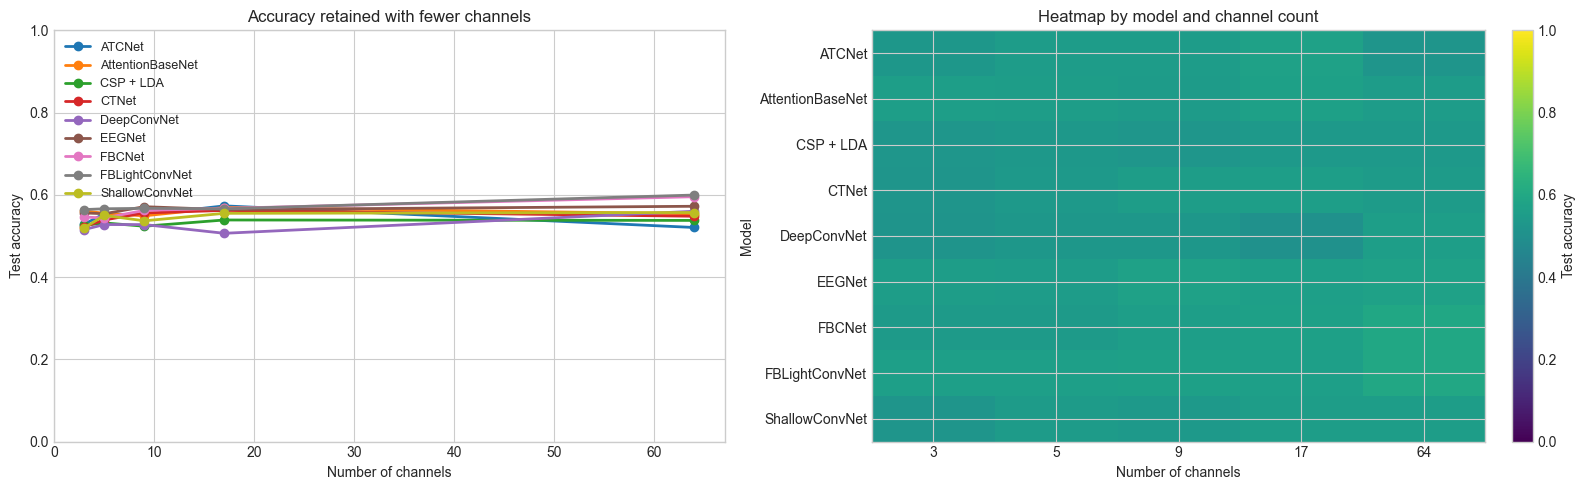

,model,best_accuracy,min_channels_within_tolerance,recommended_subset,recommended_accuracy
1,AttentionBaseNet,0.569262,3,motor_strip_3,0.561173
5,EEGNet,0.572295,3,motor_strip_3,0.556117
2,CSP + LDA,0.538928,3,motor_strip_3,0.525784
0,ATCNet,0.573306,5,motor_strip_5,0.554095
8,ShallowConvNet,0.557128,5,motor_strip_5,0.550051
3,CTNet,0.562184,9,sensorimotor_9,0.556117
7,FBLightConvNet,0.599596,64,all_channels,0.599596
6,FBCNet,0.595551,64,all_channels,0.595551
4,DeepConvNet,0.560162,64,all_channels,0.560162


In [9]:
successful_sweep = channel_sweep_results.query("status == 'ok'").copy()

if not successful_sweep.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for model_name, model_df in successful_sweep.groupby("model"):
        model_df = model_df.sort_values("n_channels")
        axes[0].plot(
            model_df["n_channels"],
            model_df["test_accuracy"],
            marker="o",
            linewidth=2,
            label=model_name,
        )
    axes[0].set_title("Accuracy retained with fewer channels")
    axes[0].set_xlabel("Number of channels")
    axes[0].set_ylabel("Test accuracy")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].legend(loc="best", fontsize=9)

    pivot = (
        successful_sweep.pivot_table(
            index="model", columns="n_channels", values="test_accuracy", aggfunc="max"
        )
        .sort_index()
        .sort_index(axis=1)
    )
    image = axes[1].imshow(
        pivot.values, aspect="auto", cmap="viridis", vmin=0.0, vmax=1.0
    )
    axes[1].set_title("Heatmap by model and channel count")
    axes[1].set_xlabel("Number of channels")
    axes[1].set_ylabel("Model")
    axes[1].set_xticks(np.arange(len(pivot.columns)))
    axes[1].set_xticklabels(pivot.columns.astype(int))
    axes[1].set_yticks(np.arange(len(pivot.index)))
    axes[1].set_yticklabels(pivot.index)
    fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04, label="Test accuracy")

    plt.tight_layout()
    plt.show()

    min_channel_summary = summarize_min_channels(
        successful_sweep, tolerance=MIN_CHANNEL_TOLERANCE
    )
    display(min_channel_summary)
